# scitex_seizure_metrics — `bridge`: sample ↔ alarm analytic bounds

Most published seizure-prediction papers report **either** sample-based metrics (AUROC, Brier) **or** alarm-based metrics (sensitivity, FP/hr) — not both. `scitex_seizure_metrics.bridge` derives the analytic relationship so you can place any single-regime paper on the other regime's axis without re-running their pipeline.

**What this notebook covers**

1. `bridge.sample_to_alarm` — convert a (sensitivity, specificity) pair into upper bounds on (alarm sensitivity, FP/hr).
2. Sweep across realistic policy parameters (SOP, cadence) to see how the bound moves.
3. Visualise the achievable region — the published paper plots as a single point; scitex_seizure_metrics shows you the envelope it lives in.

---
**figrecipe drop-in note** — this notebook uses `figrecipe.subplots()` instead of `matplotlib.pyplot.subplots()`. figrecipe returns a `RecordingFigure` + `RecordingAxes` pair that proxies every standard matplotlib method, so every line below is a verbatim copy of the matplotlib version — no API changes — but the figure can now also be saved as a reproducible bundle via `fg.save(fig, 'recipe.zip')`.

**Terminology** (the jargon used below; see the project README for the full glossary):

| Term | Meaning |
| --- | --- |
| **SPH** (`sph_seconds`) | *Seizure-Prediction Horizon* — minimum lead-time between an alarm firing and the seizure onset. Alarms that fire later than SPH before the seizure are not credited. |
| **SOP** (`sop_seconds`) | *Seizure-Occurrence Period* — the window after SPH during which the predicted seizure must actually occur for the alarm to count as a true positive. Defines `[SPH, SPH + SOP]`. |
| **Cadence** (`cadence_seconds`) | How often a fresh "is the warning on?" decision is emitted. |
| **Refractory** (`refractory_seconds`) | Post-alarm silent window that suppresses redundant alarms around a single seizure. |
| **FP/hr** | False-positive alarms per hour, normalised by `fp_denominator`: `'total'` recording time (Cook 2013, Karoly 2017) or `'interictal'`-only time (Mormann tradition). |
| **IoC** | *Improvement over Chance* — signed gap between the model's alarm-based sensitivity and a chance-baseline (Poisson surrogate by default). |
| **TIW** | *Time-In-Warning* — fraction of recording time the warning is active. The natural denominator that pairs with sensitivity in the Proix 2021 operating curve. |
| **AUROC / AUPRC / Brier / MCC / ECE** | Sample-based metrics (per-window classification). See `01_detection_quick_start.ipynb` and the README glossary. |


In [1]:
%matplotlib inline
import warnings

warnings.filterwarnings('ignore', category=UserWarning)

import figrecipe as fg  # drop-in: returns RecordingFigure / RecordingAxes
import numpy as np
import pandas as pd

import scitex_seizure_metrics
from scitex_seizure_metrics import bridge

scitex_seizure_metrics.__version__

'0.1.0'

## 1. Single conversion

Suppose a paper reports sample-based sensitivity = 0.79 and specificity = 0.85 with a 10-minute SOP and 60-second alarm cadence. What does that imply for the alarm-based metrics?

In [2]:
bnd = bridge.sample_to_alarm(
    sample_sensitivity=0.79,
    sample_specificity=0.85,
    sop_seconds=600,
    cadence_seconds=60,
    refractory_seconds=600,
    prevalence=0.05,
)
print(f'alarm sensitivity (upper bound)  : {bnd.alarm_sensitivity_upper:.3f}')
print(f'FP per hour       (upper bound)  : {bnd.fp_per_hour_upper:.3f}')

alarm sensitivity (upper bound)  : 0.790
FP per hour       (upper bound)  : 6.000


## 2. Sweep over SOP

The seizure-occurrence period (SOP) is the window after SPH within which the predicted seizure must actually occur for the alarm to count as a true positive. Longer SOP relaxes both bounds.

In [3]:
sop_grid = np.array([300, 600, 1200, 1800, 3600], dtype=float)
rows = []
for sop in sop_grid:
    b = bridge.sample_to_alarm(
        sample_sensitivity=0.79,
        sample_specificity=0.85,
        sop_seconds=float(sop),
        cadence_seconds=60,
        refractory_seconds=600,
        prevalence=0.05,
    )
    rows.append({'sop_seconds': sop, 'alarm_sens_upper': b.alarm_sensitivity_upper, 'fp_per_hour_upper': b.fp_per_hour_upper})
df_sop = pd.DataFrame(rows)
df_sop.round(3)

,sop_seconds,alarm_sens_upper,fp_per_hour_upper
0,300.0,0.790,6.0
1,600.0,0.790,6.0
2,1200.0,0.790,6.0
3,1800.0,0.956,6.0
4,3600.0,0.991,6.0


Text(0.5, 1.0, 'FP/hr bound vs SOP')

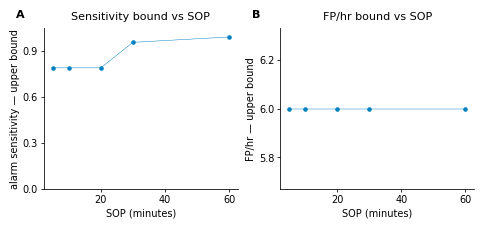

In [4]:
fig, axes = fg.subplots(1, 2)
axes[0].plot(df_sop['sop_seconds'] / 60, df_sop['alarm_sens_upper'], 'o-')
axes[0].set_xlabel('SOP (minutes)')
axes[0].set_ylabel('alarm sensitivity — upper bound')
axes[0].set_title('Sensitivity bound vs SOP')
axes[0].set_ylim(0, 1.05)
axes[1].plot(df_sop['sop_seconds'] / 60, df_sop['fp_per_hour_upper'], 'o-')
axes[1].set_xlabel('SOP (minutes)')
axes[1].set_ylabel('FP/hr — upper bound')
axes[1].set_title('FP/hr bound vs SOP')


## 3. Sweep over prevalence

Prevalence — the fraction of recording time labelled pre-ictal — is the lever a paper has the most freedom to pick. The bridge's prevalence-aware K-effective term means a single (sensitivity, specificity) pair maps to **different** alarm bounds depending on the dataset's prevalence.

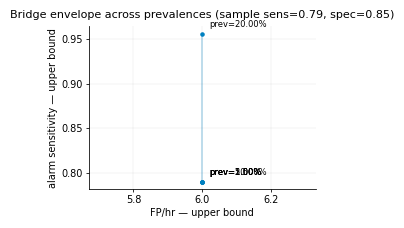

In [5]:
prev_grid = np.array([0.01, 0.025, 0.05, 0.10, 0.20])
rows = []
for prev in prev_grid:
    b = bridge.sample_to_alarm(
        sample_sensitivity=0.79,
        sample_specificity=0.85,
        sop_seconds=600,
        cadence_seconds=60,
        refractory_seconds=600,
        prevalence=float(prev),
    )
    rows.append({'prevalence': prev, 'alarm_sens_upper': b.alarm_sensitivity_upper, 'fp_per_hour_upper': b.fp_per_hour_upper})
df_prev = pd.DataFrame(rows)

fig, ax = fg.subplots()
ax.plot(df_prev['fp_per_hour_upper'], df_prev['alarm_sens_upper'], 'o-')
for _, r in df_prev.iterrows():
    ax.annotate(f"prev={r['prevalence']:.2%}", (r['fp_per_hour_upper'], r['alarm_sens_upper']),
                xytext=(5, 5), textcoords='offset points')
ax.set_xlabel('FP/hr — upper bound')
ax.set_ylabel('alarm sensitivity — upper bound')
ax.set_title('Bridge envelope across prevalences (sample sens=0.79, spec=0.85)')
ax.grid(True, alpha=0.3)


## 4. Reverse direction: alarm → sample

Going the other way is easier (no envelope — the relationship is well-determined given the same policy).

In [6]:
out = bridge.alarm_to_sample(
    alarm_sensitivity=0.85,
    fp_per_hour=0.20,
    sop_seconds=600,
    cadence_seconds=60,
    refractory_seconds=600,
    prevalence=0.05,
)
out

{'sample_sensitivity_lower': 0.85,
 'sample_sensitivity_upper': 0.85,
 'sample_specificity_lower': 0.0,
 'sample_specificity_upper': 0.9964912280701754,
 'K_effective': 1}

## Where to next

- **`05_papers_andrade2024.ipynb`** — paper-replica that uses bridge bounds to put every cited method on the same axis.
- **`scitex_seizure_metrics.surrogates`** — registry of chance-baseline alarm generators for stricter IoC nulls.